# Import Libraries

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 
import plotly.express as px
import plotly.graph_objects as go

# Load Dataset

In [2]:
uber = pd.read_csv("D:\\My DS Project\\Uber-Stock-Market-Analysis\\Data\\UBER.csv")

In [3]:
uber.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2019-05-10,42.000000,45.000000,41.060001,41.570000,41.570000,186322500
1,2019-05-13,38.790001,39.240002,36.080002,37.099998,37.099998,79442400
2,2019-05-14,38.310001,39.959999,36.849998,39.959999,39.959999,46661100
3,2019-05-15,39.369999,41.880001,38.950001,41.290001,41.290001,36086100
4,2019-05-16,41.480000,44.060001,41.250000,43.000000,43.000000,38115500


# Basic Information

In [5]:
uber.info()

<class 'pandas.DataFrame'>
RangeIndex: 725 entries, 0 to 724
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       725 non-null    str    
 1   Open       725 non-null    float64
 2   High       725 non-null    float64
 3   Low        725 non-null    float64
 4   Close      725 non-null    float64
 5   Adj Close  725 non-null    float64
 6   Volume     725 non-null    int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 46.9 KB


In [6]:
uber.shape

(725, 7)

In [7]:
uber.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [8]:
uber.duplicated().sum()

np.int64(0)

In [9]:
uber.describe()

,Open,High,Low,Close,Adj Close,Volume
count,725.000000,725.000000,725.000000,725.000000,725.000000,7.250000e+02
mean,40.166447,40.961435,39.261123,40.107255,40.107255,2.472855e+07
std,9.198940,9.259164,9.075919,9.141862,9.141862,1.691406e+07
min,15.960000,17.799999,13.710000,14.820000,14.820000,3.380000e+06
25%,32.730000,33.419998,31.983000,32.799999,32.799999,1.423060e+07
50%,39.000000,39.959999,38.009998,38.810001,38.810001,2.079540e+07
75%,46.700001,47.520000,45.860001,46.419998,46.419998,3.011960e+07
max,63.250000,64.050003,60.799999,63.180000,63.180000,1.863225e+08


# Convert Date

In [10]:
uber['Date'] = pd.to_datetime(uber['Date'])
uber.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2019-05-10,42.000000,45.000000,41.060001,41.570000,41.570000,186322500
1,2019-05-13,38.790001,39.240002,36.080002,37.099998,37.099998,79442400
2,2019-05-14,38.310001,39.959999,36.849998,39.959999,39.959999,46661100
3,2019-05-15,39.369999,41.880001,38.950001,41.290001,41.290001,36086100
4,2019-05-16,41.480000,44.060001,41.250000,43.000000,43.000000,38115500


# Feature Engineering

In [11]:
uber['Year'] = uber['Date'].dt.year
uber['Month'] = uber['Date'].dt.month_name()
uber['Day'] = uber['Date'].dt.day
uber['Weekday'] = uber['Date'].dt.day_name()

# EDA (Exploratory Data Analysis)

Graph 1

Closing Price Trend

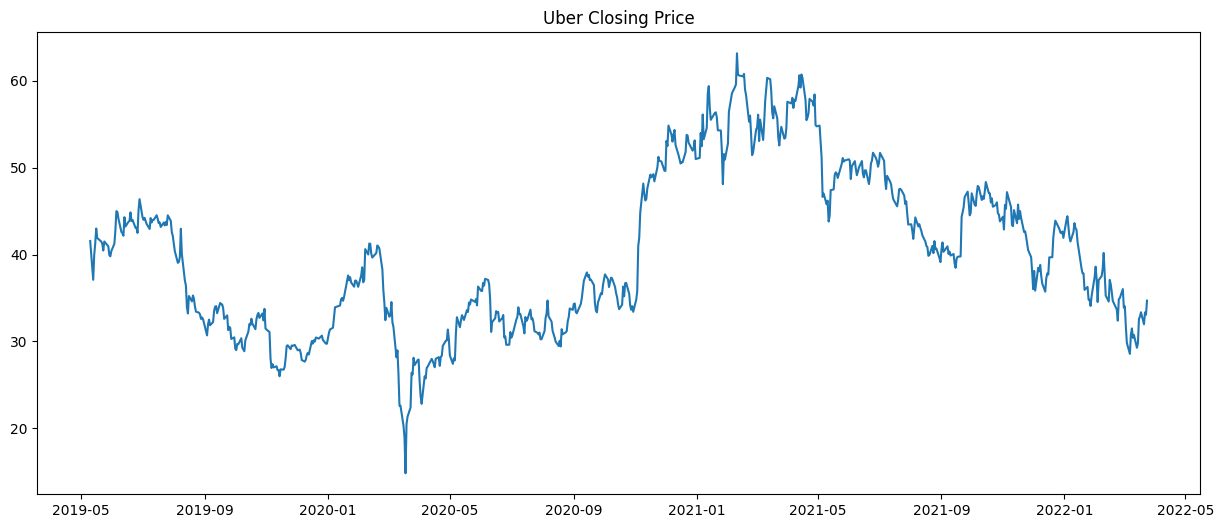

In [35]:
plt.figure(figsize=(15,6))
plt.plot(uber['Date'],uber['Close'])
plt.title("Uber Closing Price")
plt.savefig("images/closing_price.png", dpi=300, bbox_inches="tight")
plt.show()

Graph 2

Volume Trend

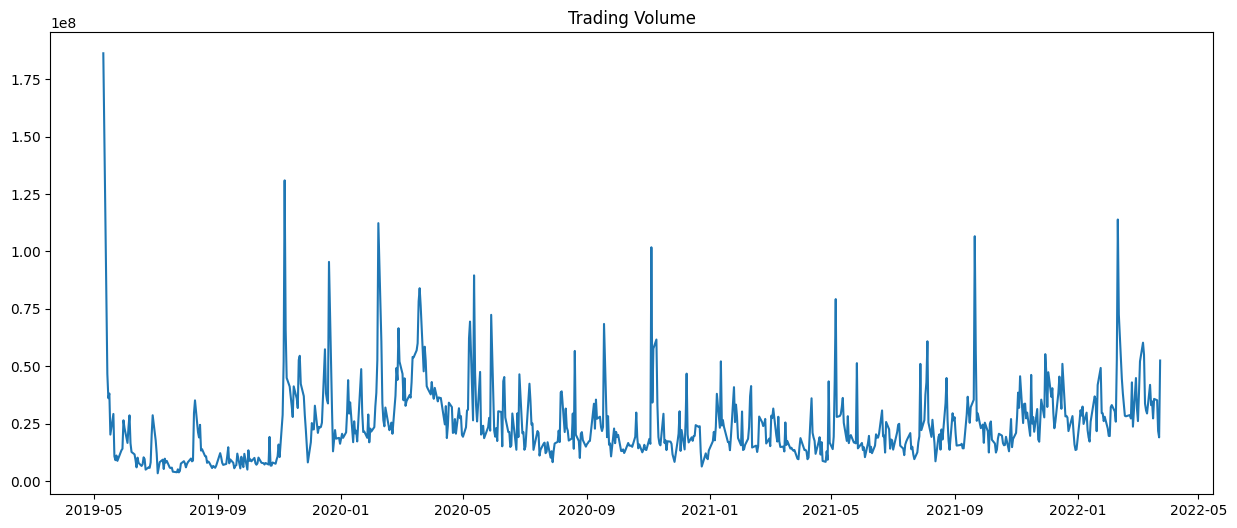

In [36]:
plt.figure(figsize=(15,6))
plt.plot(uber['Date'],uber['Volume'])
plt.title("Trading Volume")
plt.savefig("images/Trading Volume.png", dpi=300, bbox_inches="tight")
plt.show()

Graph 3

Open vs Close

<Axes: xlabel='Open', ylabel='Close'>

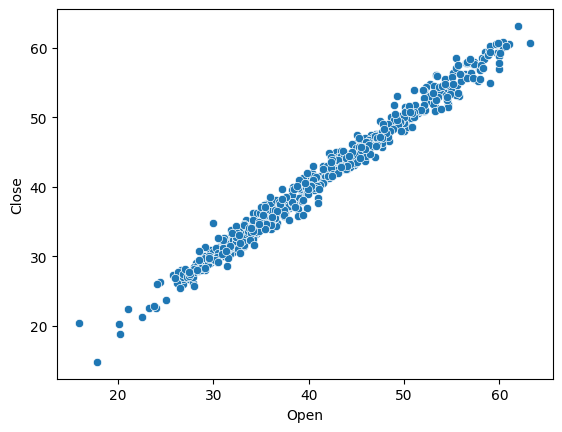

In [15]:
plt.Figure(figsize=(10,6))
sns.scatterplot(data=uber,x='Open',y="Close")

# Graph 4

High vs Low

<Axes: xlabel='High', ylabel='Low'>

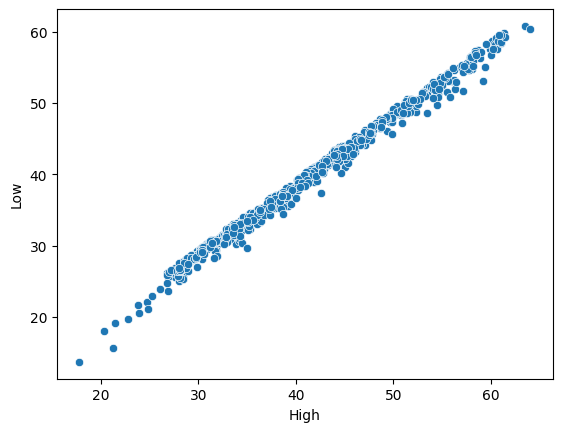

In [17]:
plt.Figure(figsize=(10,6))
sns.scatterplot(data=uber,x='High',y="Low")

Graph 5

Distribution of Closing Price

<Axes: xlabel='Close', ylabel='Count'>

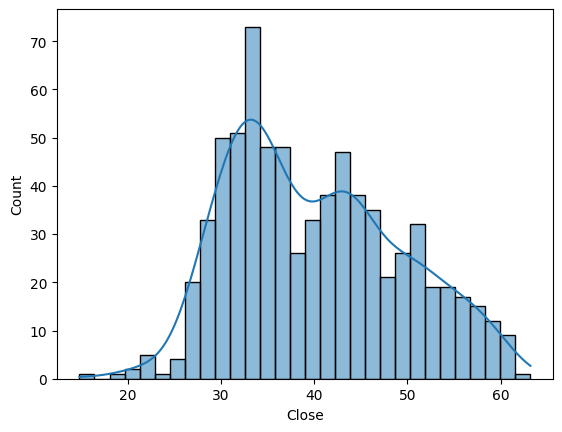

In [18]:
plt.Figure(figsize=(10,6))
sns.histplot(uber['Close'],bins=30,kde=True)


Graph 6

Boxplot

<Axes: ylabel='Close'>

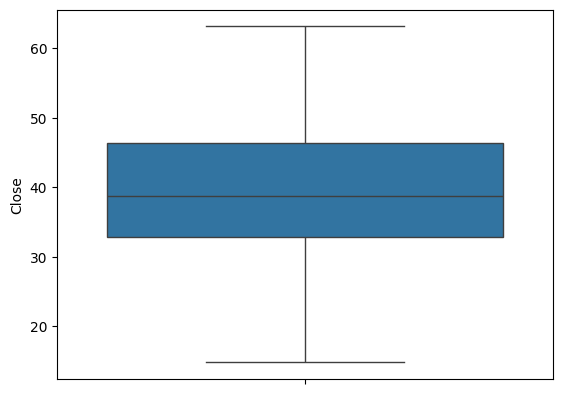

In [20]:
plt.Figure(figsize=(10,6))
sns.boxplot(uber['Close'])

Graph 7

Monthly Average Close Price

In [38]:
monthly=uber.groupby("Month")['Close'].mean().reset_index()

px.bar(monthly,
       x="Month",
       y="Close",
       title="Monthly Average Closing Price")


Graph 8

Correlation Heatmap

<Axes: >

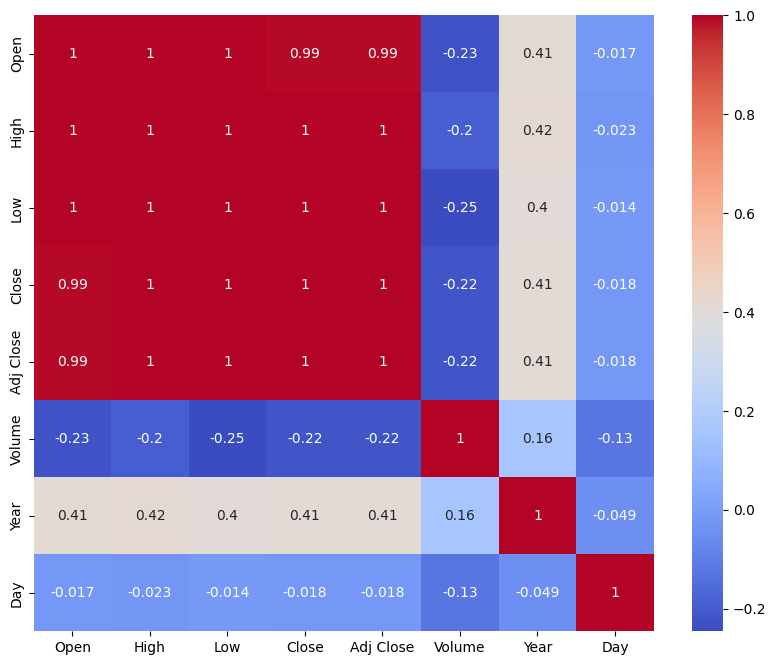

In [23]:
plt.figure(figsize=(10,8))

sns.heatmap(uber.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

Graph 9

Candlestick Chart 

In [39]:
fig=go.Figure(data=[go.Candlestick(
    x=uber['Date'],
    open=uber['Open'],
    high=uber['High'],
    low=uber['Low'],
    close=uber['Close']
)])
plt.savefig("images/Open,Low,High.png", dpi=300, bbox_inches="tight")
fig.show()

<Figure size 640x480 with 0 Axes>

Graph 10

Moving Average

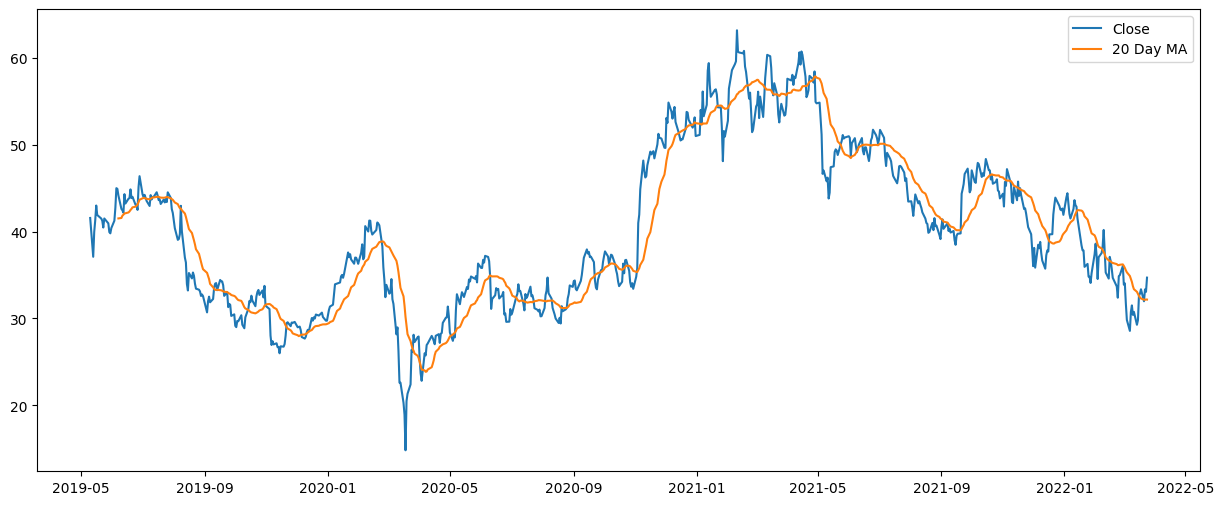

In [25]:
uber['MA20']=uber['Close'].rolling(20).mean()
plt.figure(figsize=(15,6))
plt.plot(uber['Date'],uber['Close'],label="Close")
plt.plot(uber['Date'],uber['MA20'],label="20 Day MA")
plt.legend()
plt.show()

* Daily Return

In [26]:
uber['Daily Return'] = uber['Close'].pct_change()*100

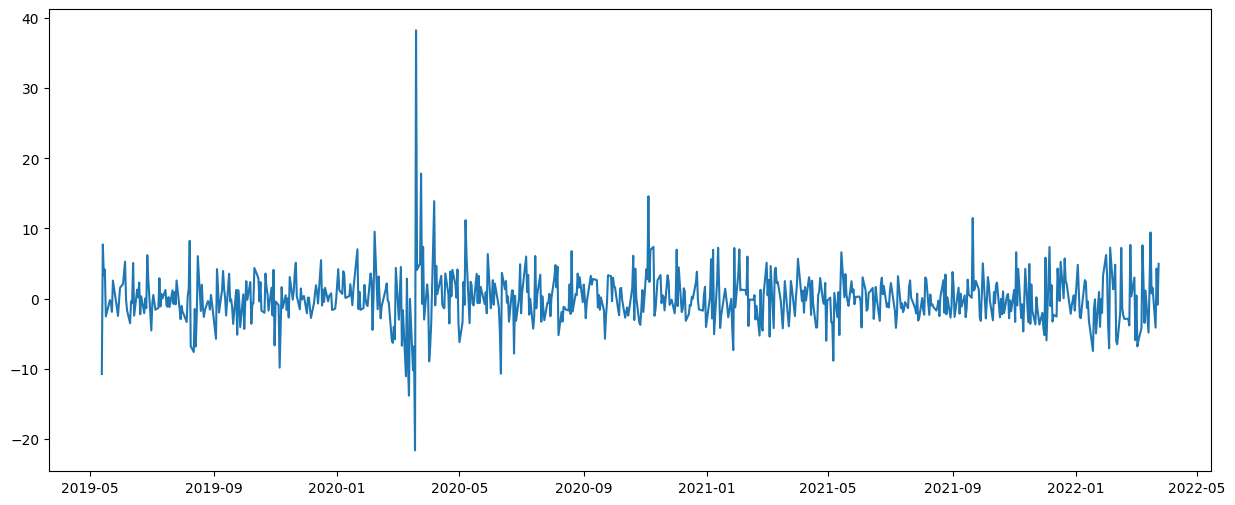

In [27]:
plt.figure(figsize=(15,6))
plt.plot(uber['Date'],uber['Daily Return'])

* Highest Trading Volume

In [28]:
uber.nlargest(10,'Volume')

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,Weekday,MA20,Daily Return
0,2019-05-10,42.000000,45.000000,41.060001,41.570000,41.570000,186322500,2019,May,10,Friday,NaN,NaN
125,2019-11-06,26.059999,27.549999,25.580000,26.940001,26.940001,130965700,2019,November,6,Wednesday,31.497500,-3.854386
695,2022-02-10,41.000000,42.560001,37.349998,37.750000,37.750000,113915000,2022,February,10,Thursday,37.410000,-6.071160
188,2020-02-07,39.980000,41.000000,38.860001,40.630001,40.630001,112325800,2020,February,7,Friday,36.528500,9.544354
596,2021-09-21,42.340000,45.000000,42.180000,44.360001,44.360001,106631700,2021,September,21,Tuesday,40.317000,11.485298
376,2020-11-04,40.660000,42.150002,39.000000,40.990002,40.990002,101818200,2020,November,4,Wednesday,35.552001,14.593240
156,2019-12-20,30.100000,31.030001,29.850000,30.450001,30.450001,95455100,2019,December,20,Friday,29.120000,1.533848
253,2020-05-12,31.420000,34.450001,30.410000,32.400002,32.400002,89586000,2020,May,12,Tuesday,29.259000,2.402032
216,2020-03-19,15.960000,21.260000,15.700000,20.490000,20.490000,83988700,2020,March,19,Thursday,29.155000,38.259109
1,2019-05-13,38.790001,39.240002,36.080002,37.099998,37.099998,79442400,2019,May,13,Monday,NaN,-10.752952


* Highest Closing Price

In [29]:
uber.nlargest(10,'Close')

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,Weekday,MA20,Daily Return
442,2021-02-10,62.000000,63.500000,60.799999,63.180000,63.180000,36972900,2021,February,10,Wednesday,55.8145,5.988926
446,2021-02-17,60.330002,60.950001,58.950001,60.810001,60.810001,12670000,2021,February,17,Wednesday,56.5415,0.479182
486,2021-04-15,59.880001,61.090000,59.549999,60.740002,60.740002,17500200,2021,April,15,Thursday,56.4970,2.549387
443,2021-02-11,63.250000,64.050003,60.395000,60.709999,60.709999,41363400,2021,February,11,Thursday,55.8800,-3.909467
484,2021-04-13,59.650002,61.009998,58.529999,60.639999,60.639999,21006100,2021,April,13,Tuesday,56.2590,2.018843
444,2021-02-12,60.119999,60.930000,59.314999,60.630001,60.630001,14607800,2021,February,12,Friday,56.0660,-0.131771
445,2021-02-16,61.020000,61.310001,59.840000,60.520000,60.520000,15413100,2021,February,16,Tuesday,56.3160,-0.181430
463,2021-03-12,58.970001,60.590000,57.619999,60.349998,60.349998,14839300,2021,March,12,Friday,56.3485,2.374889
487,2021-04-16,60.740002,60.849998,59.540001,60.349998,60.349998,11856100,2021,April,16,Friday,56.7300,-0.642088
464,2021-03-15,60.349998,60.529999,59.119999,60.189999,60.189999,14985000,2021,March,15,Monday,56.3265,-0.265118


* Lowest Closing Price

In [30]:
uber.nsmallest(10,'Close')

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,Weekday,MA20,Daily Return
215,2020-03-18,17.760000,17.799999,13.710000,14.820000,14.820000,78286200,2020,March,18,Wednesday,30.1765,-21.628768
214,2020-03-17,20.180000,20.309999,18.010000,18.910000,18.910000,60003900,2020,March,17,Tuesday,31.4880,-6.801385
213,2020-03-16,20.150000,21.490000,19.100000,20.290001,20.290001,56914000,2020,March,16,Monday,32.5515,-10.221235
216,2020-03-19,15.960000,21.260000,15.700000,20.490000,20.490000,83988700,2020,March,19,Thursday,29.1550,38.259109
217,2020-03-20,22.530001,23.889999,20.610001,21.330000,21.330000,76529700,2020,March,20,Friday,28.1855,4.099561
218,2020-03-23,21.070000,22.730000,19.730000,22.400000,22.400000,47787100,2020,March,23,Monday,27.3900,5.016409
212,2020-03-13,24.010000,24.809999,21.129999,22.600000,22.600000,53844400,2020,March,13,Friday,33.5200,-0.044233
211,2020-03-12,23.260000,24.690001,22.110001,22.610001,22.610001,54042000,2020,March,12,Thursday,34.3945,-13.833838
227,2020-04-03,23.730000,23.790001,21.670000,22.820000,22.820000,40572000,2020,April,3,Friday,24.1240,-3.631757
226,2020-04-02,25.010000,25.200001,23.000000,23.680000,23.680000,35838200,2020,April,2,Thursday,24.5670,-6.845004


* Yearly Statistics

In [31]:
uber.groupby("Year")['Close'].agg(['mean','max','min'])

,mean,max,min
Year,,,
2019,35.537669,46.380001,25.99
2020,35.511660,54.860001,14.82
2021,48.610040,63.180000,35.73
2022,35.981403,44.419998,28.57
